# M87 Black Hole Image Reconstruction 🌌

In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd
from pathlib import Path
import os

arr = os.listdir()
arr = os.listdir('data/EHTC_FirstM87Results_Apr2019/')
print(arr)
print("All Imports Succesful!")

['csv', 'INVENTORY.txt', 'LICENSE.txt', 'README.md', 'run.sh', 'txt', 'uvfits']
All Imports Succesful!


## Exploring the Data 🗂️

In [2]:
file = Path(
    "data/EHTC_FirstM87Results_Apr2019/"
    "uvfits/SR1_M87_2017_095_hi_hops_netcal_StokesI.uvfits"
)

hdul = fits.open(file)

print(hdul.info())

Filename: data\EHTC_FirstM87Results_Apr2019\uvfits\SR1_M87_2017_095_hi_hops_netcal_StokesI.uvfits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 GroupsHDU       82   (3, 4, 1, 1, 1, 1)   float32   6458 Groups  9 Parameters
  1  AIPS AN       1 BinTableHDU     60   8R x 13C   [8A, 3D, 1E, 1J, 1J, 1E, 1A, 1E, 3E, 1A, 1E, 3E, 1D]   
  2  AIPS FQ       1 BinTableHDU     21   1R x 5C   [1J, 1D, 1E, 1E, 1J]   
None


In [3]:
for key in ["OBJECT", "TELESCOP", "DATE-OBS", "NAXIS", "NAXIS1", "NAXIS2", "NAXIS3", "NAXIS4"]:
    print(key, "=", hdul[0].header.get(key))

OBJECT = M87
TELESCOP = VLBA
DATE-OBS = 2017-04-05
NAXIS = 7
NAXIS1 = 0
NAXIS2 = 3
NAXIS3 = 4
NAXIS4 = 1


In [4]:
data = hdul[0].data
row = data[0]

print("u =", row["UU---SIN"])
print("v =", row["VV---SIN"])
print("w =", row["WW---SIN"])
print("baseline =", row["BASELINE"])
print("integration time =", row["INTTIM"])

print("\nDATA:")
print(row["DATA"])

u = 0.004722165171029005
v = -0.016735978524097875
w = 0.0
baseline = 261.0
integration time = 8.8

DATA:
[[[[[[-6.9170073e-03 -1.2506705e-02  1.4626225e+04]
     [-6.9170073e-03 -1.2506705e-02  1.4626225e+04]
     [ 0.0000000e+00  0.0000000e+00            inf]
     [ 0.0000000e+00  0.0000000e+00            inf]]]]]]


Now we have the basic strucure of the data figured out we can turn it into a pandas DataFrame which will make it much easier to work with. The original UVFITS format contains the measurements in a multidimensional array, which can be difficult to work with directly. A DataFrame gives us a much simpler table containing the quantities we will use during the reconstruction:

* `u` — Fourier-plane u coordinate
* `v` — Fourier-plane v coordinate
* `real` — real component of the complex visibility
* `imag` — imaginary component of the complex visibility
* `weight` — measurement weight

This should give us one row per measurement, with 6,458 measurements in total.

In [5]:
u = data["UU---SIN"]
v = data["VV---SIN"]

squeezed = np.squeeze(data["DATA"])
real = squeezed[:, 0, 0]
imag = squeezed[:, 0, 1]
weight = squeezed[:, 0, 2]
print("u:", u.shape)
print("v:", v.shape)
print("real:", real.shape)
print("imag:", imag.shape)
print("weight:", weight.shape)

u: (6458,)
v: (6458,)
real: (6458,)
imag: (6458,)
weight: (6458,)


In [6]:
df = pd.DataFrame({
    "u": np.asarray(u, dtype=np.float64),
    "v": np.asarray(v, dtype=np.float64),
    "real": np.asarray(real, dtype=np.float64),
    "imag": np.asarray(imag, dtype=np.float64),
    "weight": np.asarray(weight, dtype=np.float64),
})

Find our Reference Frequency to turn `U` and `V` into wavelengths 

In [7]:
print("Frequency:", hdul[0].header["CRVAL4"], "Hz")
print("Frequency in GHz:", hdul[0].header["CRVAL4"] / 1e9)
frequencyRef = hdul[0].header["CRVAL4"]  


Frequency: 229070703125.0 Hz
Frequency in GHz: 229.070703125


### Derived Visibility Quantities 📐

The real and imaginary components describe the complex visibility measured by the interferometer.

From these components We can calculate two useful quantities:

- **Amplitude** — the magnitude of the visibility
- **Phase** — the angle of the complex visibility

I will also calculate the length of each u-v coordinate, which represents the projected baseline length in Gλ.

These derived quantities will make it easier to explore the measurements before attempting image reconstruction.

In [8]:
u_Glambda = u * frequencyRef * 1e-9
v_Glambda = v * frequencyRef * 1e-9
visibility = df["real"] + 1j * df["imag"]

df["amplitude"] = np.abs(visibility)
df["phase"] = np.angle(visibility)
visibility = df["real"].to_numpy() + 1j * df["imag"].to_numpy()

df["baseline_Glambda"] = np.sqrt(
    u_Glambda**2 + v_Glambda**2
)

df.head()

,u,v,real,imag,weight,amplitude,phase,baseline_Glambda
0,0.004722,-0.016736,-0.006917,-0.012507,14626.224609,0.014292,-2.075989,3.983406
1,-0.019208,-0.019686,0.136019,0.013969,20262.142578,0.136734,0.102343,6.300383
2,0.000004,-0.000008,0.591577,0.950759,18189.121094,1.119780,1.014202,0.001914
3,0.004718,-0.016728,-0.013640,-0.012420,251.636246,0.018448,-2.402974,3.981516
4,-0.019211,-0.019678,0.075689,-0.117322,470.743378,0.139619,-0.997846,6.299718


In [9]:
df.describe()

,u,v,real,imag,weight,amplitude,phase,baseline_Glambda
count,6458.000000,6458.000000,6458.000000,6458.000000,6458.000000,6458.000000,6458.000000,6458.000000
mean,0.002803,-0.008056,0.038120,-0.034986,16311.485095,0.196015,-0.036386,4.405517
std,0.017265,0.009721,0.167509,0.313576,29388.546355,0.301062,1.788456,2.237669
min,-0.035953,-0.023935,-0.573433,-1.127424,9.505354,0.000682,-3.141436,0.000120
25%,-0.013033,-0.016996,-0.058960,-0.059417,170.723003,0.066466,-1.543896,3.174885
50%,0.008771,-0.006250,0.005303,-0.006416,563.861542,0.095699,-0.163481,4.315167
75%,0.013603,0.001423,0.081591,0.056140,20338.513672,0.131856,1.492440,6.325937
max,0.035953,0.006053,1.104441,1.116309,169243.468750,1.127822,3.141125,8.334719


## U-V Coverage Plot 📈

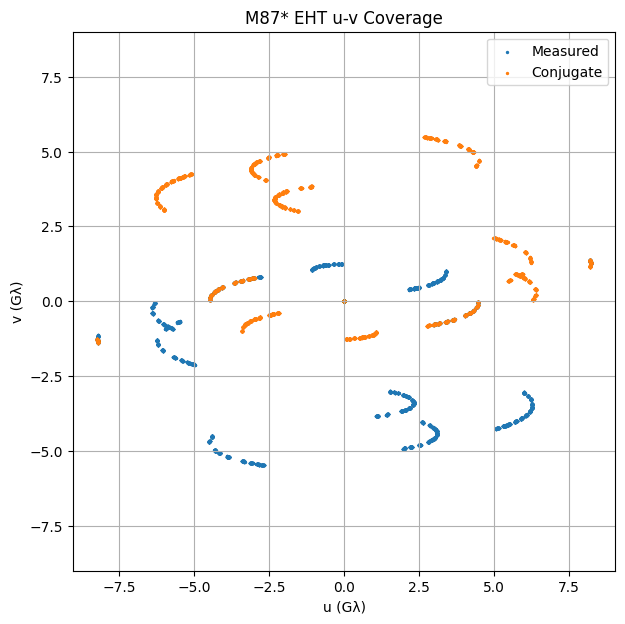

In [10]:
plt.figure(figsize=(7, 7)) 
plt.scatter(u_Glambda, v_Glambda, s=2, label="Measured") 
plt.scatter(-u_Glambda, -v_Glambda, s=2, label="Conjugate") 
plt.xlabel("u (Gλ)") 
plt.ylabel("v (Gλ)") 
plt.title("M87* EHT u-v Coverage") 
plt.axis("equal") 
plt.grid(True) 
plt.legend() 
plt.show()

## Plotting Visibility Amplitude vs. Baseline Length 

### Plotting the Raw Data

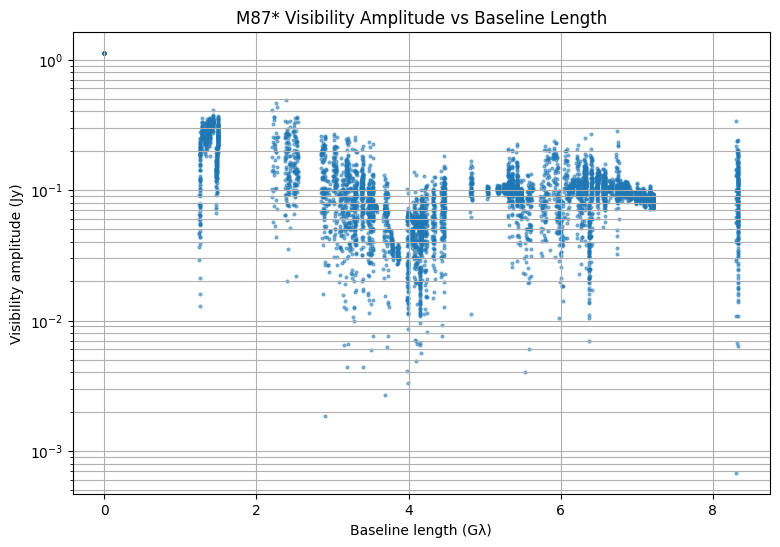

In [11]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["baseline_Glambda"],
    df["amplitude"],
    s=4,
    alpha=0.5
)

plt.yscale("log")

plt.xlabel("Baseline length (Gλ)")
plt.ylabel("Visibility amplitude (Jy)")
plt.title("M87* Visibility Amplitude vs Baseline Length")

plt.grid(True, which="both")

plt.show()

### Plotting into bins 

Number of bin centres: 38
Number of amplitude values: 38


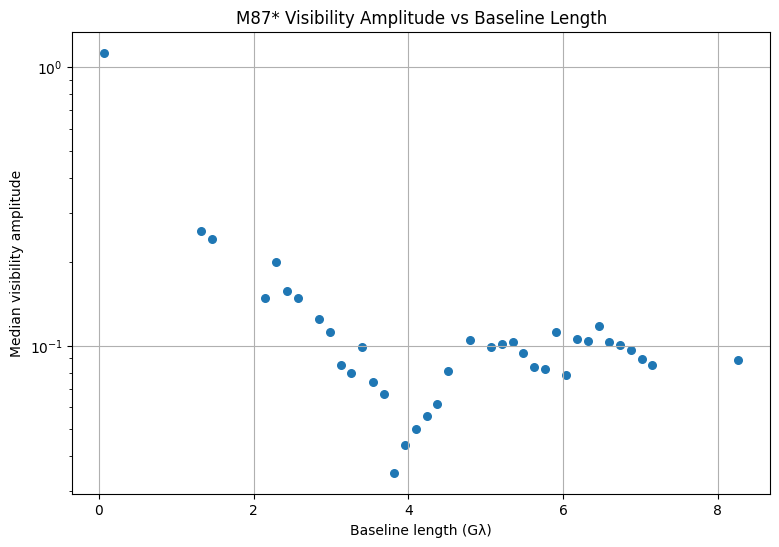

In [12]:
n_bins = 60
bin_edges = np.linspace(
    df["baseline_Glambda"].min(),
    df["baseline_Glambda"].max(),
    n_bins + 1
)

df["baseline_bin"] = pd.cut(
    df["baseline_Glambda"],
    bins=bin_edges
)

grouped = df.groupby("baseline_bin", observed=True)
binned_amplitude = grouped["amplitude"].median()
bin_centers = np.array([
    interval.mid
    for interval in binned_amplitude.index
])
print("Number of bin centres:", len(bin_centers))
print("Number of amplitude values:", len(binned_amplitude))
plt.figure(figsize=(9, 6))

plt.scatter(
    bin_centers,
    binned_amplitude,
    s=30
)

plt.xlabel("Baseline length (Gλ)")
plt.ylabel("Median visibility amplitude")
plt.title("M87* Visibility Amplitude vs Baseline Length")
plt.yscale("log")
plt.grid(True)
plt.show()

This plot resembles the plot displayed in the Event Horizon Offical Paper with peaks at 0Gλ and 5.5Gλ as well as a dip at 3.5Gλ 

## Investigating Visibility Weights ⚖️

Each visibility measurement has an associated weight. The weight describes how strongly that measurement should contribute when the data are combined or used in an imaging process.

In [13]:
print(df["weight"].describe())

count      6458.000000
mean      16311.485095
std       29388.546355
min           9.505354
25%         170.723003
50%         563.861542
75%       20338.513672
max      169243.468750
Name: weight, dtype: float64


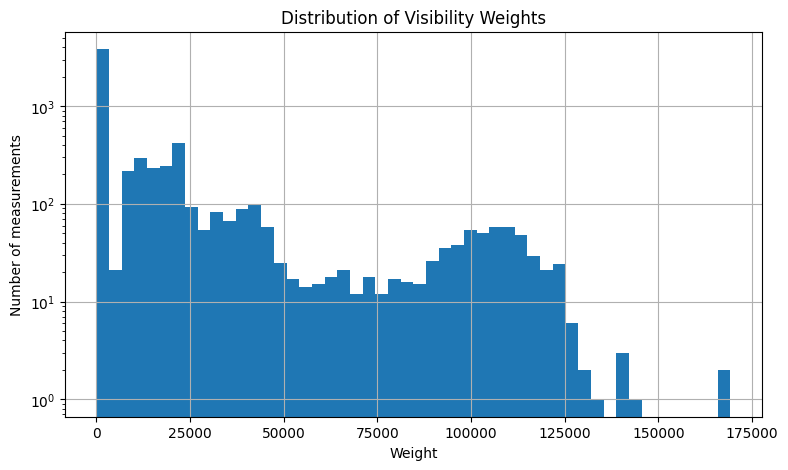

In [14]:
plt.figure(figsize=(9, 5))

plt.hist(df["weight"], bins=50)

plt.xlabel("Weight")
plt.ylabel("Number of measurements")
plt.title("Distribution of Visibility Weights")
plt.yscale("log")
plt.grid(True)
plt.show()

DATA shape: (6458, 1, 1, 1, 1, 4, 3)
u shape: (6458,)
v shape: (6458,)
raw shape: (6458, 1, 1, 1, 1, 4, 3)
Stokes-I visibility shape: (6458,)
Raw weight range: 9.505353927612305 to 169243.46875
Valid measurements: 6458
Reference frequency: 229.070703125 GHz
Baseline range: 0.00011978331435521775 to 8.334719002878957 Gλ
Visibility amplitude: 0.0006816321445037927 to 1.1278216998566724 Jy


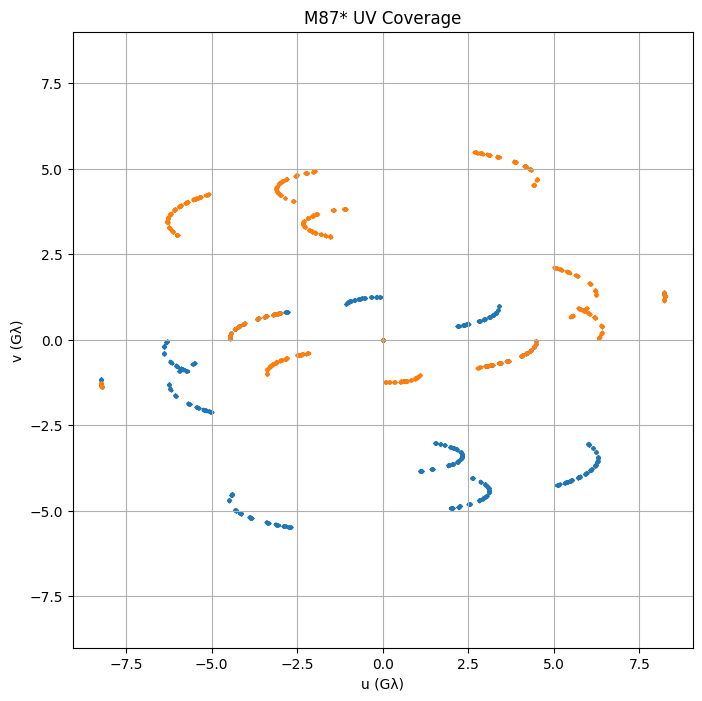


Image: 1024 x 1024
FOV: 160.0 μas
Pixel: 0.15625 μas
UV spacing: 1.2891550390443522 Gλ
UV grid limit: 660.0473799907084 Gλ
Samples placed on grid: 12916
Occupied UV cells: 49


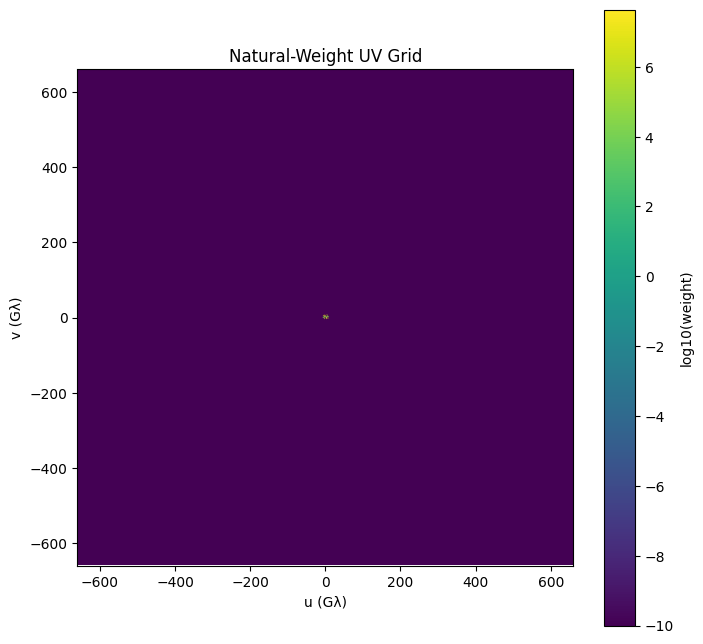

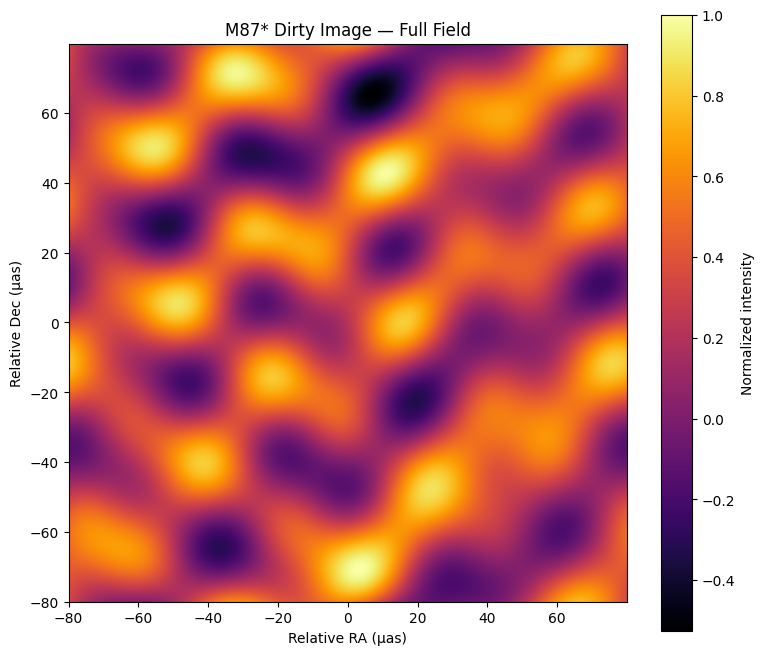

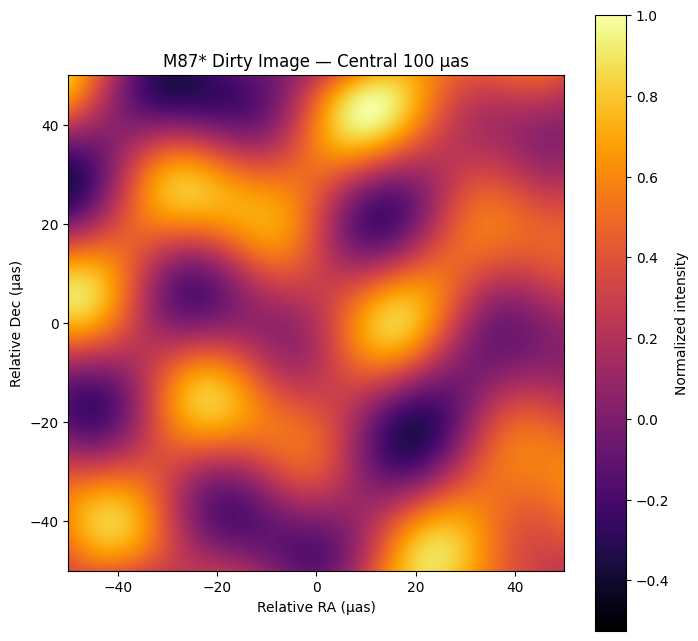

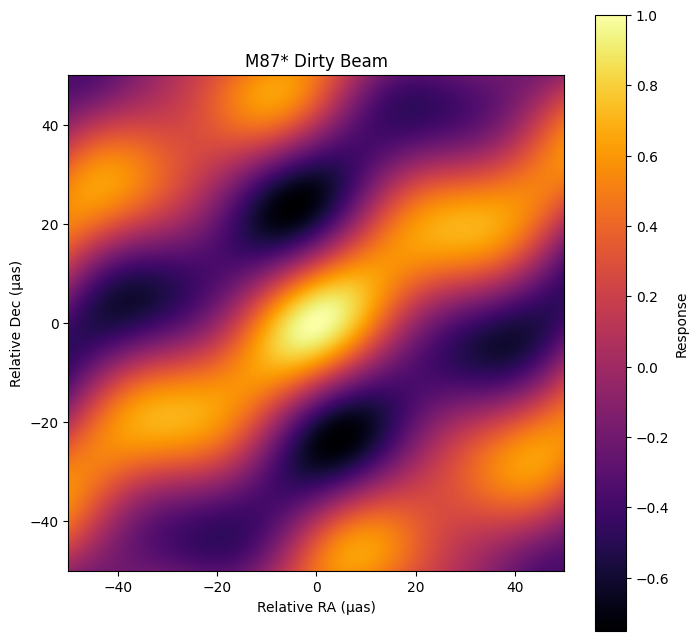

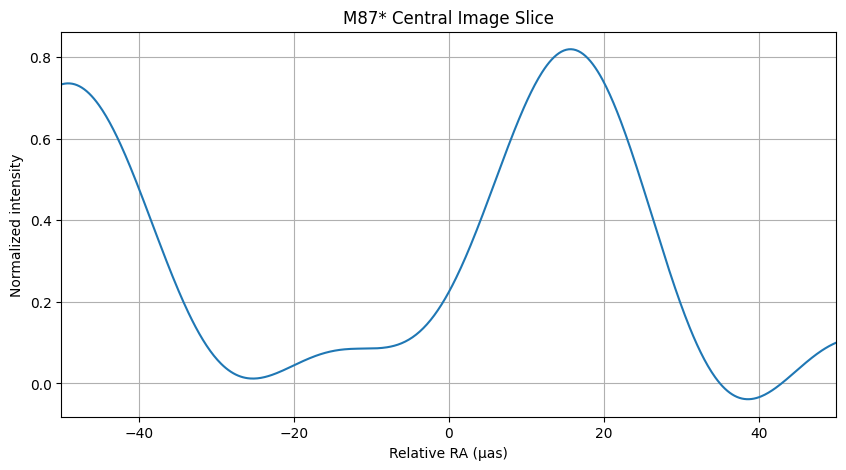


FINAL IMAGING CHECK
Valid visibilities: 6458
UV cells: 49
Maximum baseline: 8.334719002878957 Gλ
Image FOV: 160.0 μas
Pixel size: 0.15625 μas
Image minimum: -0.5250423820617884
Image maximum: 1.0
Beam minimum: -0.7516490592492064
Beam maximum: 1.0


In [15]:
# %% [markdown]
# ============================================================
# M87* EHT — DIRTY IMAGE RECONSTRUCTION
# ============================================================
#
# This version works directly from the UVFITS random groups.
#
# IMPORTANT:
# We first make a simple, correctly normalized dirty image.
# CLEAN / regularized reconstruction comes AFTER this works.
# ============================================================

# %%
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. READ RANDOM-GROUP DATA
# ============================================================

data = hdul[0].data

print("DATA shape:", data["DATA"].shape)

# UVFITS random-group parameters
u_sec = np.asarray(data["UU---SIN"], dtype=np.float64)
v_sec = np.asarray(data["VV---SIN"], dtype=np.float64)

raw = np.asarray(data["DATA"], dtype=np.float64)

print("u shape:", u_sec.shape)
print("v shape:", v_sec.shape)
print("raw shape:", raw.shape)


# ============================================================
# 2. EXTRACT STOKES-I
# ============================================================
#
# DATA has final dimensions:
#
#        4, 3
#
# The final axis contains:
#
#        real
#        imaginary
#        weight
#
# The preceding axis contains the four Stokes products.
#
# For this Stokes-I UVFITS:
#        index 0 = Stokes I
#
# ============================================================

stokes_I = raw[:, 0, 0, 0, 0, 0, :]

real = stokes_I[:, 0]
imag = stokes_I[:, 1]
weight = stokes_I[:, 2]

visibility = real + 1j * imag

print("Stokes-I visibility shape:", visibility.shape)

print(
    "Raw weight range:",
    np.nanmin(weight),
    "to",
    np.nanmax(weight)
)


# ============================================================
# 3. VALID DATA MASK
# ============================================================

good = (
    np.isfinite(u_sec) &
    np.isfinite(v_sec) &
    np.isfinite(real) &
    np.isfinite(imag) &
    np.isfinite(weight) &
    (weight > 0)
)

u_sec = u_sec[good]
v_sec = v_sec[good]
visibility = visibility[good]
weight = weight[good]

print("Valid measurements:", len(visibility))


# ============================================================
# 4. CONVERT UV COORDINATES TO WAVELENGTHS
# ============================================================

frequency = hdul[0].header["CRVAL4"]

u_lambda = u_sec * frequency
v_lambda = v_sec * frequency

baseline = np.sqrt(
    u_lambda**2 +
    v_lambda**2
)

print(
    "Reference frequency:",
    frequency / 1e9,
    "GHz"
)

print(
    "Baseline range:",
    baseline.min() / 1e9,
    "to",
    baseline.max() / 1e9,
    "Gλ"
)


# ============================================================
# 5. VISIBILITY AMPLITUDE CHECK
# ============================================================

amplitude = np.abs(visibility)

print(
    "Visibility amplitude:",
    amplitude.min(),
    "to",
    amplitude.max(),
    "Jy"
)


# ============================================================
# 6. SHOW ACTUAL UV COVERAGE FIRST
# ============================================================

plt.figure(figsize=(8, 8))

plt.scatter(
    u_lambda / 1e9,
    v_lambda / 1e9,
    s=2
)

plt.scatter(
    -u_lambda / 1e9,
    -v_lambda / 1e9,
    s=2
)

plt.xlabel("u (Gλ)")
plt.ylabel("v (Gλ)")
plt.title("M87* UV Coverage")

plt.axis("equal")
plt.grid(True)

plt.show()


# ============================================================
# 7. IMAGE GEOMETRY
# ============================================================

N = 1024

# 160 microarcseconds gives enough room around M87*
fov_uas = 160.0

# radians per microarcsecond
uas_to_rad = np.deg2rad(1.0 / 3600.0) / 1e6

pixel_uas = fov_uas / N
pixel_rad = pixel_uas * uas_to_rad

# Fourier-plane spacing
du = 1.0 / (N * pixel_rad)

print()
print("Image:", N, "x", N)
print("FOV:", fov_uas, "μas")
print("Pixel:", pixel_uas, "μas")
print("UV spacing:", du / 1e9, "Gλ")


# ============================================================
# 8. UV LIMIT
# ============================================================

uv_limit = N * du / 2

print(
    "UV grid limit:",
    uv_limit / 1e9,
    "Gλ"
)

if baseline.max() > uv_limit:
    print(
        "WARNING: some baselines fall outside the image UV grid"
    )


# ============================================================
# 9. ADD HERMITIAN CONJUGATES
# ============================================================

u_all = np.concatenate([
    u_lambda,
    -u_lambda
])

v_all = np.concatenate([
    v_lambda,
    -v_lambda
])

vis_all = np.concatenate([
    visibility,
    np.conj(visibility)
])

weight_all = np.concatenate([
    weight,
    weight
])


# ============================================================
# 10. UV INDICES
# ============================================================

u_idx = np.rint(
    u_all / du + N / 2
).astype(int)

v_idx = np.rint(
    v_all / du + N / 2
).astype(int)

inside = (
    (u_idx >= 0) &
    (u_idx < N) &
    (v_idx >= 0) &
    (v_idx < N)
)

u_idx = u_idx[inside]
v_idx = v_idx[inside]

vis_all = vis_all[inside]
weight_all = weight_all[inside]

print(
    "Samples placed on grid:",
    len(vis_all)
)


# ============================================================
# 11. NATURAL-WEIGHT UV GRIDDING
# ============================================================

uv_sum = np.zeros(
    (N, N),
    dtype=np.complex128
)

weight_grid = np.zeros(
    (N, N),
    dtype=np.float64
)

np.add.at(
    uv_sum,
    (v_idx, u_idx),
    vis_all * weight_all
)

np.add.at(
    weight_grid,
    (v_idx, u_idx),
    weight_all
)

occupied = weight_grid > 0

uv_grid = np.zeros(
    (N, N),
    dtype=np.complex128
)

uv_grid[occupied] = (
    uv_sum[occupied]
    /
    weight_grid[occupied]
)

print(
    "Occupied UV cells:",
    occupied.sum()
)


# ============================================================
# 12. NATURAL-WEIGHT DIRTY IMAGE
# ============================================================

# Use the accumulated weights directly.
#
# This is important:
# the dirty image is the weighted inverse Fourier transform
# of the measured visibilities.

weighted_uv = (
    uv_grid * weight_grid
)

dirty = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(weighted_uv)
    )
).real


# ============================================================
# 13. NORMALIZE TO TOTAL FLUX
# ============================================================
#
# The absolute FFT normalization isn't useful for display.
# Normalize only for visualization.

dirty /= np.max(
    np.abs(dirty)
)


# ============================================================
# 14. DIRTY BEAM
# ============================================================

dirty_beam = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(weight_grid)
    )
).real

dirty_beam /= np.max(
    np.abs(dirty_beam)
)


# ============================================================
# 15. IMAGE COORDINATES
# ============================================================

axis = (
    np.arange(N) - N // 2
) * pixel_uas

extent = [
    axis[0],
    axis[-1],
    axis[0],
    axis[-1]
]


# ============================================================
# 16. UV WEIGHT MAP
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    np.log10(
        weight_grid + 1e-10
    ),
    origin="lower",
    extent=[
        -uv_limit / 1e9,
         uv_limit / 1e9,
        -uv_limit / 1e9,
         uv_limit / 1e9
    ]
)

plt.xlabel("u (Gλ)")
plt.ylabel("v (Gλ)")
plt.title("Natural-Weight UV Grid")

plt.colorbar(
    label="log10(weight)"
)

plt.show()


# ============================================================
# 17. DIRTY IMAGE — FULL FIELD
# ============================================================

plt.figure(figsize=(9, 8))

plt.imshow(
    dirty,
    origin="lower",
    cmap="inferno",
    extent=extent
)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Dirty Image — Full Field")

plt.colorbar(
    label="Normalized intensity"
)

plt.show()


# ============================================================
# 18. DIRTY IMAGE — CENTRAL REGION
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    dirty,
    origin="lower",
    cmap="inferno",
    extent=extent
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Dirty Image — Central 100 μas")

plt.colorbar(
    label="Normalized intensity"
)

plt.show()


# ============================================================
# 19. DIRTY BEAM
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    dirty_beam,
    origin="lower",
    cmap="inferno",
    extent=extent
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Dirty Beam")

plt.colorbar(
    label="Response"
)

plt.show()


# ============================================================
# 20. CENTRAL CUT
# ============================================================

centre = N // 2

central_row = dirty[centre, :]

plt.figure(figsize=(10, 5))

plt.plot(
    axis,
    central_row
)

plt.xlim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Normalized intensity")
plt.title("M87* Central Image Slice")

plt.grid(True)

plt.show()


# ============================================================
# 21. FINAL CHECKS
# ============================================================

print()
print("=" * 50)
print("FINAL IMAGING CHECK")
print("=" * 50)

print(
    "Valid visibilities:",
    len(visibility)
)

print(
    "UV cells:",
    occupied.sum()
)

print(
    "Maximum baseline:",
    baseline.max() / 1e9,
    "Gλ"
)

print(
    "Image FOV:",
    fov_uas,
    "μas"
)

print(
    "Pixel size:",
    pixel_uas,
    "μas"
)

print(
    "Image minimum:",
    dirty.min()
)

print(
    "Image maximum:",
    dirty.max()
)

print(
    "Beam minimum:",
    dirty_beam.min()
)

print(
    "Beam maximum:",
    dirty_beam.max()
)

DATA shape: (6458, 1, 1, 1, 1, 4, 3)
Valid measurements: 6458
Frequency: 229.070703125 GHz
Maximum baseline: 8.334719002878957 Gλ

Image size: 2048 x 2048
Field of view: 2000.0 μas
Pixel size: 0.9765625 μas
UV cell size: 0.1031324031235482 Gλ
UV grid limit: 105.60758079851335 Gλ
Samples inside grid: 12916

Occupied UV cells: 297
Fraction of UV cells occupied: 7.081031799316406e-05


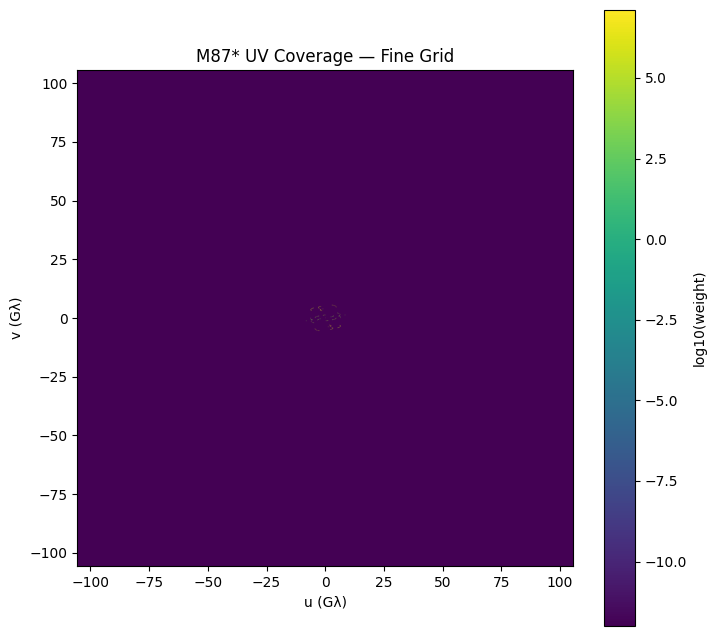

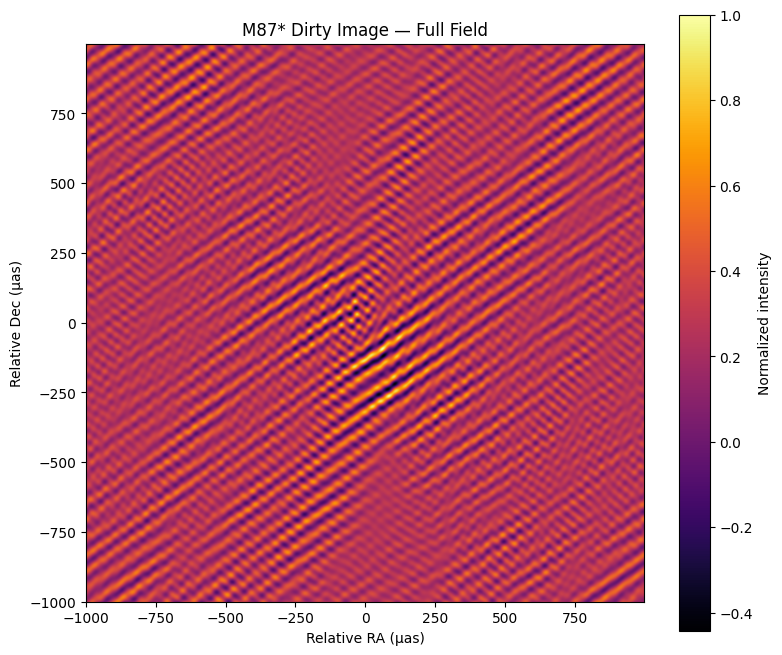

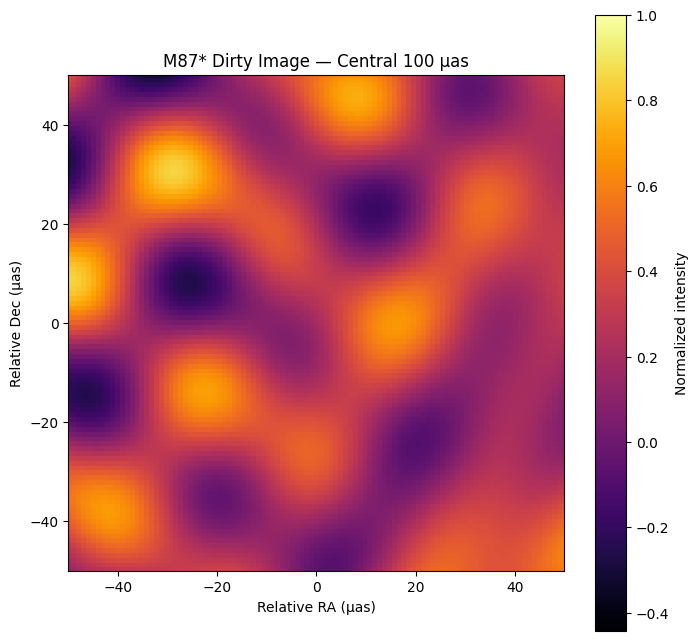

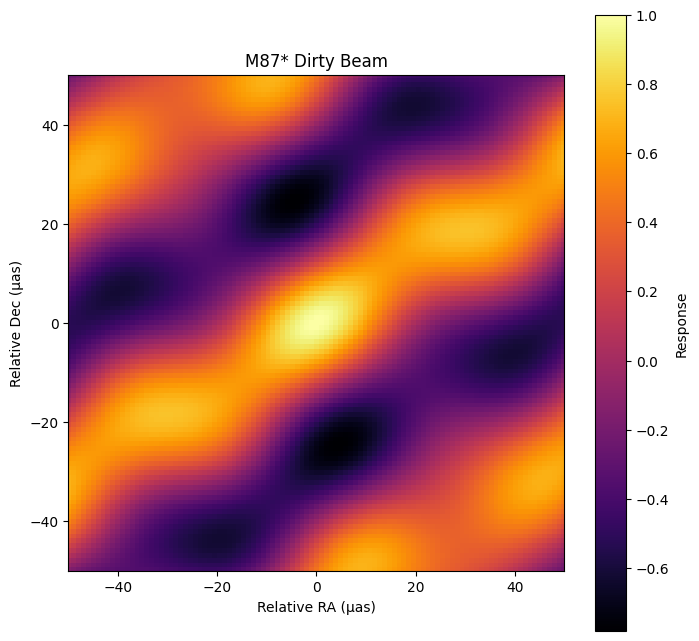


M87* IMAGING DIAGNOSTICS
Valid visibilities: 6458
UV cells: 297
Maximum baseline: 8.334719002878957 Gλ
UV cell size: 0.1031324031235482 Gλ
Image FOV: 2000.0 μas
Pixel size: 0.9765625 μas
Dirty image min: -0.4426385
Dirty image max: 1.0
Dirty beam min: -0.78285646
Dirty beam max: 1.0


In [16]:
# %% [markdown]
# ============================================================
# M87* EHT IMAGE RECONSTRUCTION — FINER UV GRID
# ============================================================
#
# The previous version used a UV cell size of ~1.29 Gλ.
# That collapsed 6458 measurements into only 49 cells.
#
# Here we use:
#
#   N       = 2048
#   FOV     = 2000 μas
#   pixel   ≈ 0.98 μas
#   UV cell ≈ 0.103 Gλ
#
# The displayed image is then cropped to the central region.
# ============================================================

# %%

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. READ THE UVFITS RANDOM-GROUP DATA
# ============================================================

data = hdul[0].data
raw = np.asarray(data["DATA"], dtype=np.float64)

u_sec = np.asarray(
    data["UU---SIN"],
    dtype=np.float64
)

v_sec = np.asarray(
    data["VV---SIN"],
    dtype=np.float64
)

print("DATA shape:", raw.shape)


# ============================================================
# 2. EXTRACT STOKES I
# ============================================================

# Final DATA axis:
#
# [0] real
# [1] imaginary
# [2] weight
#
# The preceding axis selects Stokes I.

stokes_I = raw[:, 0, 0, 0, 0, 0, :]

real = stokes_I[:, 0]
imag = stokes_I[:, 1]
weight = stokes_I[:, 2]

visibility = real + 1j * imag


# ============================================================
# 3. REMOVE INVALID MEASUREMENTS
# ============================================================

good = (
    np.isfinite(u_sec) &
    np.isfinite(v_sec) &
    np.isfinite(real) &
    np.isfinite(imag) &
    np.isfinite(weight) &
    (weight > 0)
)

u_sec = u_sec[good]
v_sec = v_sec[good]
visibility = visibility[good]
weight = weight[good]

print("Valid measurements:", len(visibility))


# ============================================================
# 4. CONVERT UV COORDINATES TO WAVELENGTHS
# ============================================================

frequency = hdul[0].header["CRVAL4"]

u_lambda = u_sec * frequency
v_lambda = v_sec * frequency

baseline = np.sqrt(
    u_lambda**2 +
    v_lambda**2
)

print(
    "Frequency:",
    frequency / 1e9,
    "GHz"
)

print(
    "Maximum baseline:",
    baseline.max() / 1e9,
    "Gλ"
)


# ============================================================
# 5. ADD HERMITIAN CONJUGATES
# ============================================================

u_all = np.concatenate([
    u_lambda,
    -u_lambda
])

v_all = np.concatenate([
    v_lambda,
    -v_lambda
])

vis_all = np.concatenate([
    visibility,
    np.conj(visibility)
])

weight_all = np.concatenate([
    weight,
    weight
])


# ============================================================
# 6. IMAGE GEOMETRY
# ============================================================

N = 2048

# Large field gives us a fine UV grid.
fov_uas = 2000.0

uas_to_rad = (
    np.pi /
    (180.0 * 3600.0 * 1e6)
)

pixel_uas = fov_uas / N
pixel_rad = pixel_uas * uas_to_rad

# Fourier-plane cell spacing
du = 1.0 / (
    N * pixel_rad
)

uv_limit = (
    N * du / 2.0
)

print()
print("Image size:", N, "x", N)
print("Field of view:", fov_uas, "μas")
print("Pixel size:", pixel_uas, "μas")
print("UV cell size:", du / 1e9, "Gλ")
print("UV grid limit:", uv_limit / 1e9, "Gλ")


# ============================================================
# 7. GRID THE UV DATA
# ============================================================

u_idx = np.rint(
    u_all / du + N / 2
).astype(np.int64)

v_idx = np.rint(
    v_all / du + N / 2
).astype(np.int64)

inside = (
    (u_idx >= 0) &
    (u_idx < N) &
    (v_idx >= 0) &
    (v_idx < N)
)

u_idx = u_idx[inside]
v_idx = v_idx[inside]

vis_all = vis_all[inside]
weight_all = weight_all[inside]

print(
    "Samples inside grid:",
    len(vis_all)
)


# ============================================================
# 8. NATURAL-WEIGHT GRIDDING
# ============================================================

uv_sum = np.zeros(
    (N, N),
    dtype=np.complex64
)

weight_grid = np.zeros(
    (N, N),
    dtype=np.float32
)

np.add.at(
    uv_sum,
    (v_idx, u_idx),
    (vis_all * weight_all).astype(np.complex64)
)

np.add.at(
    weight_grid,
    (v_idx, u_idx),
    weight_all.astype(np.float32)
)

occupied = weight_grid > 0

uv_grid = np.zeros(
    (N, N),
    dtype=np.complex64
)

uv_grid[occupied] = (
    uv_sum[occupied] /
    weight_grid[occupied]
)

print()
print("Occupied UV cells:", occupied.sum())


# ============================================================
# 9. IMPORTANT SANITY CHECK
# ============================================================

print(
    "Fraction of UV cells occupied:",
    occupied.mean()
)

if occupied.sum() < 500:
    print(
        "WARNING: UV grid is still too coarse."
    )
else:
    print(
        "UV grid has enough occupied cells "
        "for this first reconstruction."
    )


# ============================================================
# 10. NATURAL-WEIGHT DIRTY IMAGE
# ============================================================

weighted_uv = (
    uv_grid *
    weight_grid
)

dirty = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(
            weighted_uv
        )
    )
).real


# ============================================================
# 11. DIRTY BEAM
# ============================================================

dirty_beam = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(
            weight_grid
        )
    )
).real

dirty_beam /= np.max(
    np.abs(dirty_beam)
)


# ============================================================
# 12. NORMALIZE IMAGE FOR DISPLAY
# ============================================================

dirty /= np.max(
    np.abs(dirty)
)


# ============================================================
# 13. IMAGE COORDINATES
# ============================================================

axis_uas = (
    np.arange(N) -
    N // 2
) * pixel_uas

extent = [
    axis_uas[0],
    axis_uas[-1],
    axis_uas[0],
    axis_uas[-1]
]


# ============================================================
# 14. UV COVERAGE
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    np.log10(
        weight_grid + 1e-12
    ),
    origin="lower",
    extent=[
        -uv_limit / 1e9,
         uv_limit / 1e9,
        -uv_limit / 1e9,
         uv_limit / 1e9
    ]
)

plt.xlabel("u (Gλ)")
plt.ylabel("v (Gλ)")
plt.title("M87* UV Coverage — Fine Grid")

plt.colorbar(
    label="log10(weight)"
)

plt.show()


# ============================================================
# 15. FULL DIRTY IMAGE
# ============================================================

plt.figure(figsize=(9, 8))

plt.imshow(
    dirty,
    origin="lower",
    cmap="inferno",
    extent=extent
)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Dirty Image — Full Field")

plt.colorbar(
    label="Normalized intensity"
)

plt.show()


# ============================================================
# 16. CENTRAL 100 μas
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    dirty,
    origin="lower",
    cmap="inferno",
    extent=extent
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Dirty Image — Central 100 μas")

plt.colorbar(
    label="Normalized intensity"
)

plt.show()


# ============================================================
# 17. DIRTY BEAM
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    dirty_beam,
    origin="lower",
    cmap="inferno",
    extent=extent
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Dirty Beam")

plt.colorbar(
    label="Response"
)

plt.show()


# ============================================================
# 18. FINAL DIAGNOSTICS
# ============================================================

print()
print("=" * 60)
print("M87* IMAGING DIAGNOSTICS")
print("=" * 60)

print(
    "Valid visibilities:",
    len(visibility)
)

print(
    "UV cells:",
    occupied.sum()
)

print(
    "Maximum baseline:",
    baseline.max() / 1e9,
    "Gλ"
)

print(
    "UV cell size:",
    du / 1e9,
    "Gλ"
)

print(
    "Image FOV:",
    fov_uas,
    "μas"
)

print(
    "Pixel size:",
    pixel_uas,
    "μas"
)

print(
    "Dirty image min:",
    dirty.min()
)

print(
    "Dirty image max:",
    dirty.max()
)

print(
    "Dirty beam min:",
    dirty_beam.min()
)

print(
    "Dirty beam max:",
    dirty_beam.max()
)

In [17]:
print("Valid measurements:", len(visibility))
print("Maximum baseline:", baseline.max() / 1e9, "Gλ")
print("UV cell size:", du / 1e9, "Gλ")
print("Image FOV:", fov_uas, "μas")
print("Pixel size:", pixel_uas, "μas")
print("Occupied UV cells:", occupied.sum())

Valid measurements: 6458
Maximum baseline: 8.334719002878957 Gλ
UV cell size: 0.1031324031235482 Gλ
Image FOV: 2000.0 μas
Pixel size: 0.9765625 μas
Occupied UV cells: 297


Image pixels: 2048
Pixel size: 0.9765625 μas
UV cell: 0.1031324031235482 Gλ
CLEAN iterations: 300


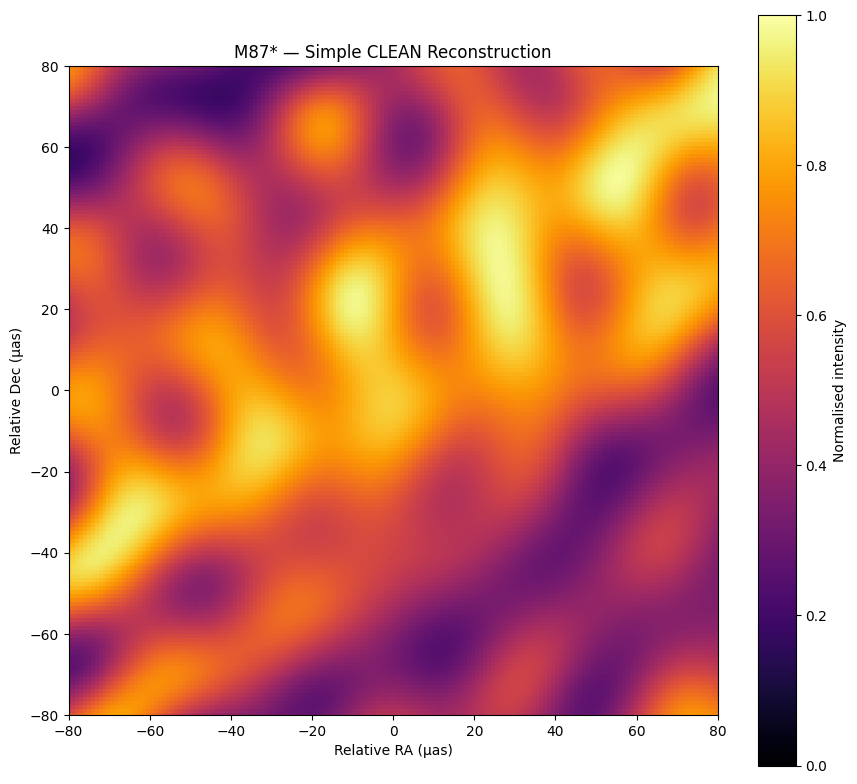

Saved: m87_clean_image.npy
Saved: m87_clean_image.png


<Figure size 640x480 with 0 Axes>

In [18]:
# %% [markdown]
# ## Simple CLEAN Reconstruction
#
# The EHT samples the Fourier transform of the source at
# discrete (u,v) coordinates. We first make a dirty image,
# then use a simple CLEAN algorithm to remove the strongest
# responses of the dirty beam.
#
# This is an educational reconstruction, not the official EHT
# imaging pipeline.

# %%

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


# ============================================================
# 1. PARAMETERS
# ============================================================

N = 2048
FOV_UAS = 2000.0

# CLEAN parameters
N_ITER = 500
GAIN = 0.1

# Width of the restoring beam in pixels.
# This is deliberately broad because this is a simple
# educational reconstruction.
RESTORE_SIGMA = 8


# ============================================================
# 2. IMAGE / UV GEOMETRY
# ============================================================

uas_to_rad = np.deg2rad(1 / 3600) / 1e6

pixel_uas = FOV_UAS / N
pixel_rad = pixel_uas * uas_to_rad

du = 1.0 / (N * pixel_rad)

print("Image pixels:", N)
print("Pixel size:", pixel_uas, "μas")
print("UV cell:", du / 1e9, "Gλ")


# ============================================================
# 3. HERMITIAN UV DATA
# ============================================================

u_all = np.concatenate([
    u_lambda,
    -u_lambda
])

v_all = np.concatenate([
    v_lambda,
    -v_lambda
])

vis_all = np.concatenate([
    visibility,
    np.conj(visibility)
])

weight_all = np.concatenate([
    weight,
    weight
])


# ============================================================
# 4. GRID VISIBILITIES
# ============================================================

u_idx = np.rint(
    u_all / du + N / 2
).astype(int)

v_idx = np.rint(
    v_all / du + N / 2
).astype(int)


inside = (
    (u_idx >= 0)
    & (u_idx < N)
    & (v_idx >= 0)
    & (v_idx < N)
)

u_idx = u_idx[inside]
v_idx = v_idx[inside]

vis_all = vis_all[inside]
weight_all = weight_all[inside]


# ============================================================
# 5. NATURAL WEIGHTING
# ============================================================

uv_sum = np.zeros(
    (N, N),
    dtype=np.complex128
)

weight_grid = np.zeros(
    (N, N),
    dtype=float
)

np.add.at(
    uv_sum,
    (v_idx, u_idx),
    vis_all * weight_all
)

np.add.at(
    weight_grid,
    (v_idx, u_idx),
    weight_all
)


# ============================================================
# 6. DIRTY IMAGE
# ============================================================

dirty = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(uv_sum)
    )
).real


# ============================================================
# 7. DIRTY BEAM
# ============================================================

dirty_beam = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(weight_grid)
    )
).real

dirty_beam /= np.max(
    np.abs(dirty_beam)
)


# ============================================================
# 8. NORMALISE DIRTY IMAGE
# ============================================================

dirty /= np.max(
    np.abs(dirty)
)


# ============================================================
# 9. SIMPLE CLEAN
# ============================================================
#
# Find the strongest residual.
# Subtract a fraction of the dirty beam centred there.
# Store that component.
# Repeat.
#

residual = dirty.copy()

components = np.zeros_like(dirty)

centre = N // 2

for iteration in range(N_ITER):

    # Find strongest positive or negative residual
    peak_index = np.unravel_index(
        np.argmax(np.abs(residual)),
        residual.shape
    )

    peak = residual[peak_index]

    # Stop when remaining structure is very small
    if np.abs(peak) < 0.02:
        break

    y, x = peak_index

    # Amount removed this iteration
    component = GAIN * peak

    components[y, x] += component

    # Shift dirty beam so its centre is at the peak
    dy = y - centre
    dx = x - centre

    shifted_beam = np.roll(
        np.roll(
            dirty_beam,
            dy,
            axis=0
        ),
        dx,
        axis=1
    )

    # Subtract the CLEAN component
    residual -= component * shifted_beam


print("CLEAN iterations:", iteration + 1)


# ============================================================
# 10. RESTORING BEAM
# ============================================================
#
# CLEAN components are delta-like pixels.
# Smooth them with a Gaussian to produce the final image.
#

restored_components = gaussian_filter(
    components,
    sigma=RESTORE_SIGMA
)


# Add the remaining residual emission
clean_image = (
    restored_components
    + residual
)


# ============================================================
# 11. NORMALISE FINAL IMAGE
# ============================================================

clean_image -= clean_image.min()

clean_image /= clean_image.max()


# ============================================================
# 12. IMAGE COORDINATES
# ============================================================

axis = (
    np.arange(N) - N // 2
) * pixel_uas

extent = [
    axis[0],
    axis[-1],
    axis[0],
    axis[-1]
]


# ============================================================
# 13. FINAL CLEAN IMAGE
# ============================================================

plt.figure(figsize=(9, 8))

plt.imshow(
    clean_image,
    origin="lower",
    cmap="inferno",
    extent=extent
)

plt.xlim(-80, 80)
plt.ylim(-80, 80)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")

plt.title(
    "M87* — Simple CLEAN Reconstruction"
)

plt.colorbar(
    label="Normalised intensity"
)

plt.tight_layout()

plt.show()


# ============================================================
# 14. SAVE
# ============================================================

np.save(
    "m87_clean_image.npy",
    clean_image
)

plt.savefig(
    "m87_clean_image.png",
    dpi=200,
    bbox_inches="tight"
)

print("Saved: m87_clean_image.npy")
print("Saved: m87_clean_image.png")